# Building-Level Population Estimation from Satellite Imagery

This notebook implements a building-centric pipeline that:
1. Loads xBD pre-disaster satellite images and their building polygon annotations
2. Crops a sub-image per building (footprint + 20 m buffer)
3. Looks up local Census demographics at each building centroid
4. Estimates building population / occupancy count
5. Packages everything into an ML-ready dataset

**Data sources**
- xBD Hurricane Harvey pre-disaster images (1024x1024 PNG, ~1.9 m GSD)
- xBD building polygon labels (pixel + geographic coords)
- US Census ACS 5-year data at Census Block Group level
- Harris County parcel data for land-use classification

In [1]:
import json
import math
import os
import random
import time
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from PIL import Image
from shapely.geometry import Polygon, Point, box
from shapely import wkt
import requests

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

print("All imports OK")

All imports OK


In [2]:
# ── Configuration ──────────────────────────────────────────────────────────

XBD_IMAGES_DIR = Path("/home/akhil.rajput/Cyber_Workshop/train/images")
XBD_LABELS_DIR = Path("/home/akhil.rajput/Cyber_Workshop/train/labels")
PARCEL_DIR     = Path("stratmap25-landparcels_48201_lp/shp")

DISASTER_PREFIX = "hurricane-harvey"     # Harris County imagery
BUFFER_METERS   = 20                     # buffer around each building
SAMPLE_IMAGES   = None                   # None = use ALL tiles
MAX_BUILDINGS   = None                   # None = keep ALL buildings
IMAGE_SIZE      = 1024                   # xBD tile side length in pixels

OUTPUT_DIR = Path("ml_dataset")
CROPS_DIR  = OUTPUT_DIR / "crops"
MASKS_DIR  = OUTPUT_DIR / "masks"
OUTPUT_DIR.mkdir(exist_ok=True)
CROPS_DIR.mkdir(exist_ok=True)
MASKS_DIR.mkdir(exist_ok=True)

# ── People-per-unit defaults (Harris County / Houston-specific) ────────────
# ACS 2022: Harris County avg household size ≈ 2.85
DEFAULT_PPU = {
    "single_family_detached": 2.85,      # Harris County ACS average
    "mobile_home":           2.4,        # smaller households typical in TX
    "duplex":                2.5,
    "triplex":               2.2,
    "small_multi_family":    2.0,        # 3–20 unit structures
    "large_multi_family":    1.7,        # 20+ unit structures (studios, 1BR)
    "unknown":               2.4,
}
DEFAULT_OCCUPANCY = 0.91                 # Harris County vacancy rate ~9%

POPULATION_CAPS = {
    "single_family_detached": 12,
    "mobile_home":            8,
    "duplex":                20,
    "triplex":               30,
    "small_multi_family":    120,        # hard cap — ~20 units × 6 ppl max
    "large_multi_family":    500,        # very large complex
    "unknown":               12,
}

# ── Footprint area thresholds for Houston (sq m) ──────────────────────────
# Houston homes are large by US standards:
#   - median new-build footprint ~180 m² (1,900 sqft, often 2-storey)
#   - large SFD footprint up to 450 m²
#   - anything > 600 m² in one polygon is very likely multi-family or non-res
SFD_MAX_FOOTPRINT     = 500      # above this → not single-family
SMALL_MF_MAX_FOOTPRINT = 2000   # above this → large multi-family

# Unit estimation: conservative because footprint ≠ total floor area,
# and xBD polygons don't carry storey count.
UNIT_AREA_PER_UNIT_SMALL_MF = 90    # ~970 sqft per unit (small walk-up)
UNIT_AREA_PER_UNIT_LARGE_MF = 80    # ~860 sqft per unit (larger complex)
MAX_UNITS_PER_FOOTPRINT     = 40    # hard cap without storey information

print("Configuration loaded")

Configuration loaded


## 1 — Load xBD Hurricane Harvey data

In [3]:
def discover_xbd_pairs(images_dir, labels_dir, prefix):
    """Find all pre-disaster image/label pairs for *prefix*."""
    pairs = []
    for fname in sorted(images_dir.glob(f"{prefix}_*_pre_disaster.png")):
        base = fname.stem.replace("_pre_disaster", "")
        label_path = labels_dir / f"{base}_pre_disaster.json"
        if label_path.exists():
            pairs.append({"base": base, "image": fname, "label": label_path})
    return pairs

all_pairs = discover_xbd_pairs(XBD_IMAGES_DIR, XBD_LABELS_DIR, DISASTER_PREFIX)
print(f"Total Harvey pre-disaster tiles: {len(all_pairs)}")

# Sample or use all tiles
if SAMPLE_IMAGES is not None:
    sampled_pairs = random.sample(all_pairs, min(SAMPLE_IMAGES, len(all_pairs)))
    print(f"Sampled {len(sampled_pairs)} tiles for processing")
else:
    sampled_pairs = all_pairs
    print(f"Using all {len(sampled_pairs)} tiles")

Total Harvey pre-disaster tiles: 319
Using all 319 tiles


In [4]:
def parse_xbd_label(label_path):
    """Parse an xBD label JSON and return a list of building dicts.

    Each dict has:
      uid          – unique building id
      poly_px      – shapely Polygon in pixel coords
      poly_geo     – shapely Polygon in lng/lat coords
      centroid_geo – shapely Point (lng, lat) of geographic centroid
    """
    with open(label_path) as f:
        data = json.load(f)

    metadata = data["metadata"]
    gsd = metadata["gsd"]          # metres per pixel

    xy_feats   = data["features"]["xy"]
    geo_feats  = data["features"]["lng_lat"]

    buildings = []
    for xy_f, geo_f in zip(xy_feats, geo_feats):
        try:
            poly_px  = wkt.loads(xy_f["wkt"])
            poly_geo = wkt.loads(geo_f["wkt"])
            if poly_px.is_empty or poly_geo.is_empty:
                continue
            buildings.append({
                "uid":          xy_f["properties"]["uid"],
                "poly_px":      poly_px,
                "poly_geo":     poly_geo,
                "centroid_geo": poly_geo.centroid,
                "gsd":          gsd,
            })
        except Exception:
            continue
    return buildings, metadata

# Parse all sampled tiles
all_buildings = []
for pair in sampled_pairs:
    bldgs, meta = parse_xbd_label(pair["label"])
    for b in bldgs:
        b["tile_base"]   = pair["base"]
        b["image_path"]  = str(pair["image"])
        b["tile_meta"]   = meta
    all_buildings.extend(bldgs)

print(f"Parsed {len(all_buildings)} buildings from {len(sampled_pairs)} tiles")

# Optionally cap to MAX_BUILDINGS
if MAX_BUILDINGS is not None and len(all_buildings) > MAX_BUILDINGS:
    all_buildings = random.sample(all_buildings, MAX_BUILDINGS)
    print(f"Sub-sampled to {len(all_buildings)} buildings")

Parsed 23014 buildings from 319 tiles


## 2 — Crop building sub-images (footprint + 20 m buffer)

In [5]:
from shapely.geometry import mapping
from PIL import ImageDraw


def crop_building_image(image_path, poly_px, gsd, buffer_m=20, img_size=1024):
    """Crop a sub-image around *poly_px* with a real-world buffer.

    Returns (cropped PIL.Image, pixel bbox used).
    """
    buffer_px = buffer_m / gsd

    minx, miny, maxx, maxy = poly_px.bounds
    x0 = max(int(minx - buffer_px), 0)
    y0 = max(int(miny - buffer_px), 0)
    x1 = min(int(maxx + buffer_px) + 1, img_size)
    y1 = min(int(maxy + buffer_px) + 1, img_size)

    img = Image.open(image_path)
    crop = img.crop((x0, y0, x1, y1))
    return crop, (x0, y0, x1, y1)


def make_binary_mask(poly_px, bbox, crop_size):
    """Render the building polygon as a binary mask within the crop bounds."""
    x0, y0 = bbox[0], bbox[1]
    shifted = [(x - x0, y - y0) for x, y in poly_px.exterior.coords]
    mask = Image.new("L", crop_size, 0)
    ImageDraw.Draw(mask).polygon(shifted, fill=255)
    return mask


crop_records = []
n_total = len(all_buildings)
for i, b in enumerate(all_buildings):
    if (i + 1) % 500 == 0 or i == 0:
        print(f"  Processing building {i+1}/{n_total} ...")
    crop_img, bbox = crop_building_image(
        b["image_path"], b["poly_px"], b["gsd"],
        buffer_m=BUFFER_METERS, img_size=IMAGE_SIZE,
    )
    fname_stem = f"{b['tile_base']}_{b['uid'][:8]}"
    crop_path = CROPS_DIR / f"{fname_stem}.png"
    mask_path = MASKS_DIR / f"{fname_stem}.png"

    crop_img.save(crop_path)
    mask_img = make_binary_mask(b["poly_px"], bbox, crop_img.size)
    mask_img.save(mask_path)

    area_sq_m = b["poly_px"].area * (b["gsd"] ** 2)

    crop_records.append({
        "building_uid":  b["uid"],
        "tile_base":     b["tile_base"],
        "crop_path":     str(crop_path),
        "mask_path":     str(mask_path),
        "crop_w":        crop_img.width,
        "crop_h":        crop_img.height,
        "bbox_px":       bbox,
        "poly_px_wkt":   b["poly_px"].wkt,
        "poly_geo_wkt":  b["poly_geo"].wkt,
        "centroid_lng":  b["centroid_geo"].x,
        "centroid_lat":  b["centroid_geo"].y,
        "gsd":           b["gsd"],
        "footprint_m2":  area_sq_m,
    })

buildings_df = pd.DataFrame(crop_records)
print(f"\nCropped {len(buildings_df)} buildings -> {CROPS_DIR}/ + {MASKS_DIR}/")
buildings_df[["building_uid", "crop_w", "crop_h", "footprint_m2"]].describe()

  Processing building 1/23014 ...


  Processing building 500/23014 ...
  Processing building 1000/23014 ...
  Processing building 1500/23014 ...
  Processing building 2000/23014 ...
  Processing building 2500/23014 ...
  Processing building 3000/23014 ...
  Processing building 3500/23014 ...
  Processing building 4000/23014 ...
  Processing building 4500/23014 ...
  Processing building 5000/23014 ...
  Processing building 5500/23014 ...
  Processing building 6000/23014 ...
  Processing building 6500/23014 ...
  Processing building 7000/23014 ...
  Processing building 7500/23014 ...
  Processing building 8000/23014 ...
  Processing building 8500/23014 ...
  Processing building 9000/23014 ...
  Processing building 9500/23014 ...
  Processing building 10000/23014 ...
  Processing building 10500/23014 ...
  Processing building 11000/23014 ...
  Processing building 11500/23014 ...
  Processing building 12000/23014 ...
  Processing building 12500/23014 ...
  Processing building 13000/23014 ...
  Processing building 13500/2301

,crop_w,crop_h,footprint_m2
count,23014.000000,23014.000000,2.301400e+04
mean,63.932476,65.036022,8.165330e+03
std,31.299681,29.129471,2.000529e+04
min,11.000000,12.000000,8.982945e+01
25%,48.000000,49.000000,3.633543e+03
50%,60.000000,62.000000,5.846003e+03
75%,72.000000,74.000000,8.253454e+03
max,1024.000000,685.000000,1.930853e+06


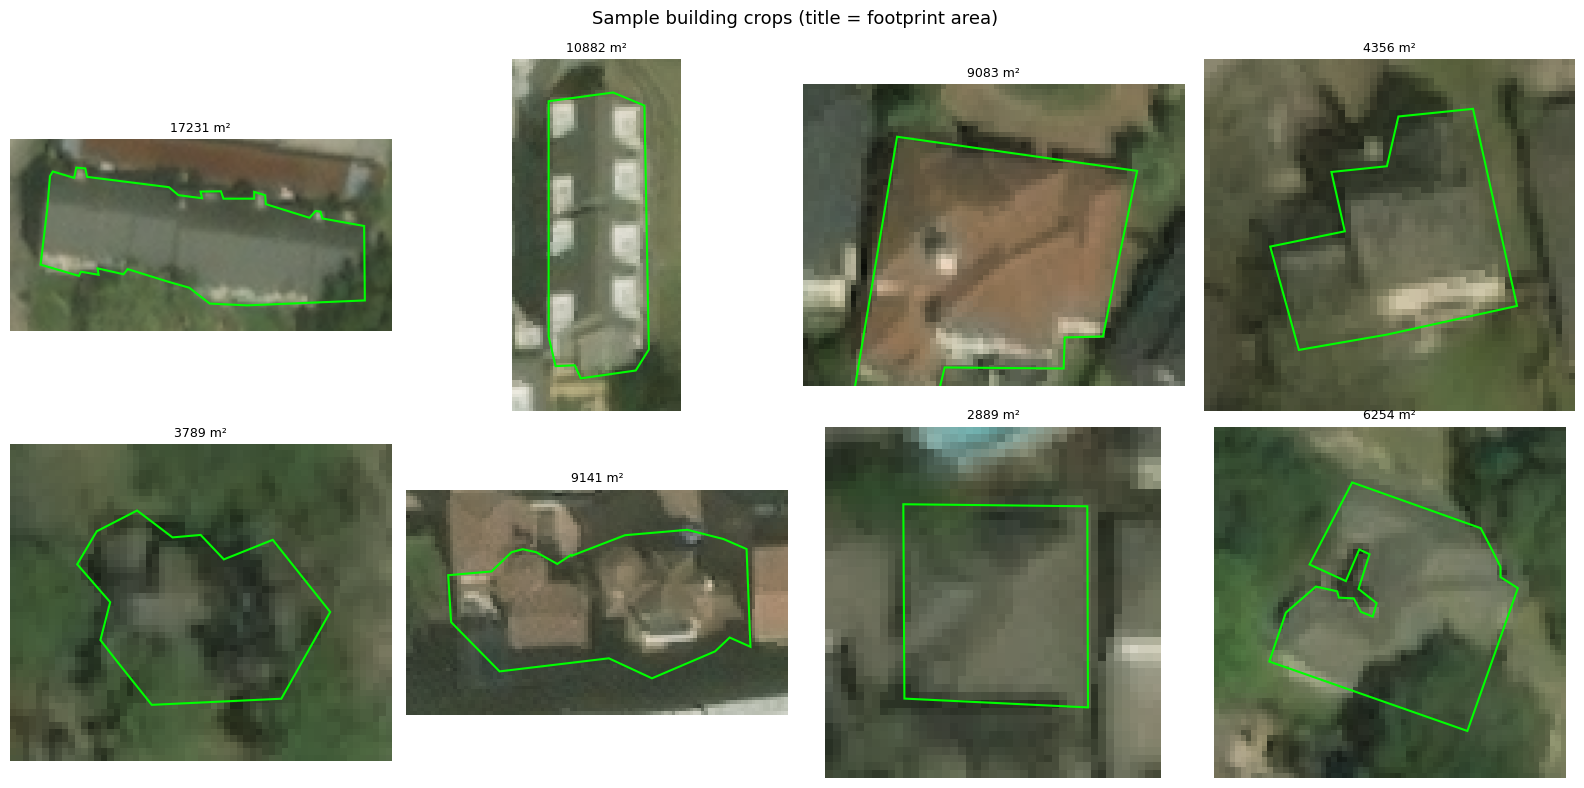

In [19]:
# Show a few sample crops with building polygon overlays
n_show = min(8, len(buildings_df))
fig, axes = plt.subplots(2, n_show // 2, figsize=(16, 8))
for ax, (_, row) in zip(axes.flat, buildings_df.sample(n_show).iterrows()):
    img = Image.open(row["crop_path"])
    ax.imshow(img)

    poly_px = wkt.loads(row["poly_px_wkt"])
    bx0, by0 = row["bbox_px"][0], row["bbox_px"][1]
    shifted = [(x - bx0, y - by0) for x, y in poly_px.exterior.coords]
    ax.add_patch(plt.Polygon(shifted, fill=False, edgecolor="lime", linewidth=1.5))

    ax.set_title(f"{row['footprint_m2']:.0f} m²", fontsize=9)
    ax.axis("off")
fig.suptitle("Sample building crops (title = footprint area)", fontsize=13)
plt.tight_layout()
plt.show()

## 3 — Census demographics at each building centroid

In [7]:
# 3a. Download Census Block Group boundaries for Harris County

TARGET_CRS = "EPSG:4326"   # WGS84 — common CRS for all spatial ops


def download_harris_cbg_boundaries():
    """Download CBG boundaries from TIGER/Line and filter to Harris County.

    TIGER/Line files ship in EPSG:4269 (NAD83).  We reproject to
    EPSG:4326 (WGS84) immediately so every downstream join/plot uses
    a single, consistent CRS.
    """
    url = "https://www2.census.gov/geo/tiger/TIGER2022/BG/tl_2022_48_bg.zip"
    print(f"Downloading CBG boundaries from {url} ...")
    cbgs = gpd.read_file(url)
    print(f"  Native CRS: {cbgs.crs}")

    harris = cbgs[cbgs["COUNTYFP"] == "201"].copy()
    harris["GEOID"] = (
        harris["STATEFP"] + harris["COUNTYFP"]
        + harris["TRACTCE"] + harris["BLKGRPCE"]
    )

    if str(harris.crs) != TARGET_CRS:
        harris = harris.to_crs(TARGET_CRS)
        print(f"  Reprojected to {TARGET_CRS}")

    print(f"  {len(harris)} Harris County Block Groups  (CRS: {harris.crs})")
    return harris

harris_cbgs = download_harris_cbg_boundaries()

  Native CRS: EPSG:4269
  Reprojected to EPSG:4326
  2830 Harris County Block Groups  (CRS: EPSG:4326)


In [8]:
# 3b. Download ACS 5-year demographic data

ACS_VARIABLES = {
    # Population in occupied housing units by units-in-structure (B25033)
    "B25033_002E": "pop_1unit_detached",
    "B25033_004E": "pop_2units",
    "B25033_005E": "pop_3to4units",
    "B25033_010E": "pop_5to9units",
    "B25033_011E": "pop_10plus_units",
    # Occupied units by structure type (B25032)
    "B25032_003E": "occ_1unit_detached",
    "B25032_004E": "occ_2units",
    "B25032_005E": "occ_3to4units",
    "B25032_008E": "occ_5to9units",
    "B25032_011E": "occ_10plus_units",
    # Total / occupied housing units (B25002)
    "B25002_001E": "total_housing_units",
    "B25002_002E": "occupied_housing_units",
}


def download_acs_data(year=2022):
    """Fetch ACS 5-year data for all Harris County block groups."""
    var_str = ",".join(ACS_VARIABLES.keys())
    url = (
        f"https://api.census.gov/data/{year}/acs/acs5"
        f"?get={var_str}&for=block+group:*&in=state:48+county:201"
    )
    print("Downloading ACS data ...")
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    rows = resp.json()
    df = pd.DataFrame(rows[1:], columns=rows[0])
    df["GEOID"] = df["state"] + df["county"] + df["tract"] + df["block group"]
    for code in ACS_VARIABLES:
        df[code] = pd.to_numeric(df[code], errors="coerce")
    df = df.rename(columns=ACS_VARIABLES)
    print(f"  {len(df)} block groups with ACS data")
    return df


acs_data = download_acs_data()

# Merge ACS into CBG geometries
harris_cbgs_acs = harris_cbgs.merge(acs_data, on="GEOID", how="left")
print(f"CBGs with ACS data: {harris_cbgs_acs['total_housing_units'].notna().sum()} / {len(harris_cbgs_acs)}")

  2830 block groups with ACS data
CBGs with ACS data: 2830 / 2830


In [9]:
# 3c. Compute people-per-unit ratios for every CBG

def safe_ratio(num, den, default):
    if pd.isna(num) or pd.isna(den) or den == 0:
        return default
    r = num / den
    return r if 0.5 <= r <= 6.0 else default


def compute_cbg_ratios(cbg_df):
    df = cbg_df.copy()
    df["ppu_single_family_detached"] = df.apply(
        lambda r: safe_ratio(r.get("pop_1unit_detached"), r.get("occ_1unit_detached"), 2.8), axis=1)
    df["ppu_mobile_home"] = df["ppu_single_family_detached"]
    df["ppu_duplex"] = df.apply(
        lambda r: safe_ratio(r.get("pop_2units"), r.get("occ_2units"), 2.5), axis=1)
    df["ppu_triplex"] = df.apply(
        lambda r: safe_ratio(r.get("pop_3to4units"), r.get("occ_3to4units"), 2.2), axis=1)
    ppu_5to9 = df.apply(
        lambda r: safe_ratio(r.get("pop_5to9units"), r.get("occ_5to9units"), 2.0), axis=1)
    ppu_10p = df.apply(
        lambda r: safe_ratio(r.get("pop_10plus_units"), r.get("occ_10plus_units"), 1.8), axis=1)
    df["ppu_multi_family"] = 0.6 * ppu_5to9 + 0.4 * ppu_10p
    df["ppu_small_multi_family"] = ppu_5to9
    df["ppu_large_multi_family"] = ppu_10p
    df["ppu_unknown"] = 0.5 * df["ppu_single_family_detached"] + 0.5 * df["ppu_multi_family"]
    df["occupancy_rate"] = df.apply(
        lambda r: safe_ratio(r.get("occupied_housing_units"), r.get("total_housing_units"), 0.90), axis=1)
    return df


harris_cbgs_acs = compute_cbg_ratios(harris_cbgs_acs)

ratio_cols = [c for c in harris_cbgs_acs.columns if c.startswith("ppu_")] + ["occupancy_rate"]
harris_cbgs_acs[ratio_cols].describe().round(2)

,ppu_single_family_detached,ppu_mobile_home,ppu_duplex,ppu_triplex,ppu_multi_family,ppu_small_multi_family,ppu_large_multi_family,ppu_unknown,occupancy_rate
count,2830.00,2830.00,2830.00,2830.00,2830.00,2830.00,2830.00,2830.00,2830.00
mean,3.12,3.12,2.49,2.20,1.93,2.01,1.82,2.53,0.91
std,0.78,0.78,0.23,0.11,0.16,0.20,0.26,0.40,0.09
min,1.00,1.00,0.51,2.12,1.08,0.60,0.53,1.46,0.50
25%,2.79,2.79,2.50,2.20,1.92,2.00,1.80,2.35,0.87
50%,2.91,2.91,2.50,2.20,1.92,2.00,1.80,2.42,0.93
75%,3.49,3.49,2.50,2.20,1.92,2.00,1.80,2.71,1.00
max,6.00,6.00,5.67,5.43,4.15,5.71,6.00,4.54,1.00


In [10]:
# 3d. Spatial join: assign each building centroid to a CBG
#
# A centroid on a CBG boundary can match two CBGs — deduplicate
# by keeping the first match per building.

centroids_gdf = gpd.GeoDataFrame(
    buildings_df,
    geometry=gpd.points_from_xy(buildings_df.centroid_lng, buildings_df.centroid_lat),
    crs=TARGET_CRS,
)

assert str(harris_cbgs_acs.crs) == TARGET_CRS, (
    f"CBG CRS mismatch: expected {TARGET_CRS}, got {harris_cbgs_acs.crs}"
)

cbg_cols = ["GEOID", "geometry", "occupancy_rate"] + [
    c for c in harris_cbgs_acs.columns if c.startswith("ppu_")
]

joined = gpd.sjoin(
    centroids_gdf, harris_cbgs_acs[cbg_cols], how="left", predicate="within"
).drop(columns=["index_right"], errors="ignore")

pre_dedup = len(joined)
joined = joined.drop_duplicates(subset="building_uid", keep="first")
print(f"Buildings matched to a CBG: {joined['GEOID'].notna().sum()} / {len(joined)}")
if pre_dedup != len(joined):
    print(f"  Deduplicated: {pre_dedup} → {len(joined)} (boundary overlaps removed)")
joined.head(3)

Buildings matched to a CBG: 21140 / 23014


,building_uid,tile_base,crop_path,mask_path,crop_w,crop_h,bbox_px,poly_px_wkt,poly_geo_wkt,centroid_lng,...,GEOID,occupancy_rate,ppu_single_family_detached,ppu_mobile_home,ppu_duplex,ppu_triplex,ppu_multi_family,ppu_small_multi_family,ppu_large_multi_family,ppu_unknown
0,c5549b70-5902-482a-9817-75dcc952a7be,hurricane-harvey_00000000,ml_dataset/crops/hurricane-harvey_00000000_c55...,ml_dataset/masks/hurricane-harvey_00000000_c55...,29,67,"(0, 150, 29, 217)","POLYGON ((0 161.2752834161872, 7.5281032424866...","POLYGON ((-95.4892325930414 29.76927046175237,...",-95.489196,...,482014303001,0.937093,2.902778,2.902778,2.5,2.2,1.92,2.0,1.8,2.411389
1,e3c03011-607b-47d3-a12c-6be51c583783,hurricane-harvey_00000000,ml_dataset/crops/hurricane-harvey_00000000_e3c...,ml_dataset/masks/hurricane-harvey_00000000_e3c...,97,132,"(146, 413, 243, 545)","POLYGON ((195.0499158724838 424.4277568004801,...",POLYGON ((-95.48826380266624 29.76818011998131...,-95.488233,...,482014303001,0.937093,2.902778,2.902778,2.5,2.2,1.92,2.0,1.8,2.411389
2,c3dd022f-8ace-43b6-a8a6-6e046b10663d,hurricane-harvey_00000000,ml_dataset/crops/hurricane-harvey_00000000_c3d...,ml_dataset/masks/hurricane-harvey_00000000_c3d...,48,46,"(143, 497, 191, 543)","POLYGON ((158.277012491073 508.2166269565598, ...",POLYGON ((-95.48843255564391 29.76782396613615...,-95.488393,...,482014303001,0.937093,2.902778,2.902778,2.5,2.2,1.92,2.0,1.8,2.411389


## 4 — Building classification & population estimation

In [11]:
# 4a. (Optional) Spatial join to Harris County parcels for land-use codes
#
# A building centroid can fall inside overlapping parcels, creating
# duplicate rows.  We keep only the first (smallest-area) parcel match
# per building to avoid inflating the dataset.

parcel_shps = list(PARCEL_DIR.glob("*.shp"))
if parcel_shps:
    print(f"Loading {len(parcel_shps)} parcel shapefiles ...")
    parcel_parts = [gpd.read_file(s) for s in parcel_shps]
    parcels = gpd.GeoDataFrame(pd.concat(parcel_parts, ignore_index=True))
    parcels.set_crs(parcel_parts[0].crs, inplace=True)
    print(f"  Parcel native CRS: {parcels.crs}")

    if str(parcels.crs) != TARGET_CRS:
        parcels = parcels.to_crs(TARGET_CRS)
        print(f"  Reprojected parcels to {TARGET_CRS}")

    parcel_cols = ["geometry", "STAT_LAND_"]
    joined = gpd.sjoin(
        joined.set_geometry(
            gpd.points_from_xy(joined.centroid_lng, joined.centroid_lat),
            crs=TARGET_CRS,
        ),
        parcels[parcel_cols],
        how="left",
        predicate="within",
    ).drop(columns=["index_right"], errors="ignore")

    pre_dedup = len(joined)
    joined = joined.drop_duplicates(subset="building_uid", keep="first")
    print(f"  Parcels matched: {joined['STAT_LAND_'].notna().sum()} / {len(joined)}")
    if pre_dedup != len(joined):
        print(f"  Deduplicated: {pre_dedup} → {len(joined)} rows "
              f"(removed {pre_dedup - len(joined)} overlapping-parcel duplicates)")
else:
    print("No parcel shapefiles found – will classify by footprint area only.")
    joined["STAT_LAND_"] = None

Loading 2 parcel shapefiles ...
  Parcel native CRS: EPSG:4326
  Parcels matched: 21007 / 23014
  Deduplicated: 100900 → 23014 rows (removed 77886 overlapping-parcel duplicates)


In [12]:
# 4b. Classify building type and estimate housing units
#
# Houston / Harris County specifics:
#   • Large single-family homes (150–500 m² footprint) are the norm
#   • xBD polygons are single-building footprints — no storey info
#   • Without storey data, unit estimates are capped conservatively
#   • Non-residential parcels get area-based occupancy instead of PPU

# Verified against HCAD State Category Codes:
# https://hcad.org/hcad-resources/hcad-appraisal-codes/hcad-state-category-codes/

RESIDENTIAL_CODES = {
    "A1": "single_family_detached",   # Single-Family Residential
    "A2": "mobile_home",              # Mobile Homes
    "A3": "single_family_detached",   # Residential (county-specific sub-type)
    "A4": "single_family_detached",   # Residential (county-specific sub-type)
    "B1": "multi_family",             # Multi-Family
    "B2": "duplex",                   # Two-Family
    "B3": "triplex",                  # Three-Family
    "B4": "multi_family",             # Four-or-More-Family
    "M3": "mobile_home",             # Tangible Mobile Homes
}

NON_RESIDENTIAL_CODES = {
    # Vacant land — no buildings, zero occupancy
    "C1": "vacant",                   # Vacant Lots/Tracts
    "C2": "vacant",                   # Vacant Commercial
    "C3": "vacant",                   # Vacant
    # Agricultural / rural
    "D1": "agricultural",             # Qualified Agricultural Land
    "D2": "agricultural",             # Unqualified Agricultural Land
    "1D1": "agricultural",            # Harris-specific variant of D1
    "E1": "agricultural",             # Farm & Ranch Improved
    "TMBR": "agricultural",           # Timber (local code)
    # Commercial & industrial
    "F1": "commercial",               # Commercial
    "F2": "industrial",               # Industrial
    # Oil / gas / minerals
    "G1": "oil_gas",                  # Oil and Mineral Gas Reserves
    # Utilities
    "J1": "utility",                  # Utility Water
    "J2": "utility",                  # Gas Companies
    "J3": "utility",                  # Electric Companies
    "J4": "utility",                  # Telephone Companies
    "J5": "utility",                  # Railroads
    "J6": "utility",                  # Pipelines
    "J7": "utility",                  # Cable Television
    # Tangible personal property (non-building)
    "L1": "commercial",               # Tangible Commercial
    "L2": "industrial",               # Tangible Industrial
    # Developer inventory — treat as vacant
    "O1": "vacant",                   # Inventory
    "O2": "vacant",                   # Inventory
    # Exempt properties (schools, churches, public, etc.)
    "X1": "institutional",            # Exempt
    "X2": "institutional",
    "X3": "institutional",
    "X4": "institutional",
    "XD": "institutional",            # Housing w/ Volunteer Labor
    "XJ": "institutional",            # Private Schools
    "XL": "institutional",            # Economic Development
    "XU": "institutional",            # Misc Exemptions
    "XV": "institutional",            # Public / Religious / Charitable
    # Unknown / other
    "Z3": "unknown_nonres",
    "Z4": "unknown_nonres",
    "Z5": "unknown_nonres",
}

# Daytime occupancy densities (people / m² of footprint)
# Adjusted for Houston: large single-storey warehouses, strip malls, etc.
NON_RES_DENSITY = {
    "commercial":    0.04,    # ~1 person per 25 m² (big-box heavy market)
    "industrial":    0.015,   # petrochemical / warehouse
    "agricultural":  0.003,   # barns, farm structures
    "oil_gas":       0.003,
    "utility":       0.003,
    "institutional": 0.06,    # schools, churches, hospitals
    "vacant":        0.0,     # no occupants on vacant land
    "unknown_nonres": 0.01,
}


def _estimate_units(area, code_type):
    """Estimate housing units from footprint area, capped conservatively."""
    if code_type in ("single_family_detached", "mobile_home"):
        return 1
    if code_type == "duplex":
        return 2
    if code_type == "triplex":
        return 3
    # Multi-family — use area-based estimate, capped
    if area < SMALL_MF_MAX_FOOTPRINT:
        units = max(1, int(area / UNIT_AREA_PER_UNIT_SMALL_MF))
    else:
        units = max(1, int(area / UNIT_AREA_PER_UNIT_LARGE_MF))
    return min(units, MAX_UNITS_PER_FOOTPRINT)


def classify_building(row):
    """Return (building_type, estimated_units, is_residential).

    When a parcel code is available we use it, but cross-check against
    the satellite footprint area.  A 5 000 m² building on an A1 (SFD)
    parcel is almost certainly a misalignment — the parcel code is
    overridden by the footprint heuristic in those cases.
    """
    code = row.get("STAT_LAND_")
    area = row["footprint_m2"]

    # ── Known residential parcel code ──
    if pd.notna(code) and code in RESIDENTIAL_CODES:
        btype = RESIDENTIAL_CODES[code]

        # Sanity check: override when footprint contradicts parcel code
        if btype in ("single_family_detached", "mobile_home") and area > SFD_MAX_FOOTPRINT:
            # Footprint far too large for a house — fall through to
            # the area-based heuristic below instead of trusting the code
            pass
        elif btype in ("duplex", "triplex") and area > SFD_MAX_FOOTPRINT * 2:
            pass  # similarly too large for a small multi-unit
        else:
            if btype == "multi_family":
                btype = ("small_multi_family" if area < SMALL_MF_MAX_FOOTPRINT
                         else "large_multi_family")
            return btype, _estimate_units(area, btype), True

    # ── Known non-residential parcel code ──
    if pd.notna(code) and code in NON_RESIDENTIAL_CODES:
        return NON_RESIDENTIAL_CODES[code], 0, False

    # ── Area-based heuristic (no parcel match, or parcel code overridden) ──
    if area < 60:
        return "unknown", 1, True
    if area <= SFD_MAX_FOOTPRINT:
        return "single_family_detached", 1, True
    if area <= SMALL_MF_MAX_FOOTPRINT:
        units = min(max(1, int(area / UNIT_AREA_PER_UNIT_SMALL_MF)),
                    MAX_UNITS_PER_FOOTPRINT)
        return "small_multi_family", units, True
    return "commercial", 0, False


classifications = joined.apply(classify_building, axis=1, result_type="expand")
joined["building_type"]   = classifications[0]
joined["estimated_units"] = classifications[1]
joined["is_residential"]  = classifications[2]

# Track whether classification came from parcel code or area heuristic
joined["classification_source"] = joined.apply(
    lambda r: "parcel_code" if (
        pd.notna(r.get("STAT_LAND_"))
        and (r["STAT_LAND_"] in RESIDENTIAL_CODES or r["STAT_LAND_"] in NON_RESIDENTIAL_CODES)
        # but only if the code wasn't overridden by the size sanity check
        and not (r["STAT_LAND_"] in RESIDENTIAL_CODES
                 and RESIDENTIAL_CODES.get(r["STAT_LAND_"]) in ("single_family_detached", "mobile_home")
                 and r["footprint_m2"] > SFD_MAX_FOOTPRINT)
    ) else "area_heuristic",
    axis=1,
)

print("Building type distribution:")
print(joined["building_type"].value_counts())
print(f"\nResidential: {joined['is_residential'].sum()}  |  "
      f"Non-residential: {(~joined['is_residential']).sum()}")
print(f"\nClassification source:")
print(joined["classification_source"].value_counts())
print(f"\nTotal estimated housing units (residential only): "
      f"{joined.loc[joined['is_residential'], 'estimated_units'].sum()}")

# Simplified 5-class mapping for ML training
TYPE_TO_CLASS = {
    "single_family_detached": 0,  # residential_small
    "mobile_home":            0,
    "duplex":                 0,
    "triplex":                0,
    "unknown":                0,
    "small_multi_family":     1,  # residential_multi
    "large_multi_family":     1,
    "commercial":             2,  # commercial
    "institutional":          3,  # institutional
    "agricultural":           4,  # other
    "industrial":             4,
    "oil_gas":                4,
    "utility":                4,
    "vacant":                 4,
    "unknown_nonres":         4,
}
CLASS_NAMES = ["residential_small", "residential_multi", "commercial",
               "institutional", "other"]

joined["type_class"] = joined["building_type"].map(TYPE_TO_CLASS).fillna(4).astype(int)
joined["type_class_name"] = joined["type_class"].map(lambda c: CLASS_NAMES[c])

print(f"\nSimplified 5-class distribution:")
print(joined["type_class_name"].value_counts())

Building type distribution:
building_type
commercial                17392
small_multi_family         2329
large_multi_family         1358
unknown_nonres              642
institutional               632
single_family_detached      349
vacant                      253
utility                      34
industrial                   13
agricultural                 12
Name: count, dtype: int64

Residential: 4036  |  Non-residential: 18978

Classification source:
classification_source
area_heuristic    18460
parcel_code        4554
Name: count, dtype: int64

Total estimated housing units (residential only): 86122

Simplified 5-class distribution:
type_class_name
commercial           17392
residential_multi     3687
other                  954
institutional          632
residential_small      349
Name: count, dtype: int64


In [13]:
# 4c. Estimate population / occupancy per building
#
# Residential buildings  → housing-based: units × PPU ratio × occupancy rate
# Non-residential buildings → area-based:  footprint_m² × occupancy density

def estimate_population(row):
    btype = row["building_type"]
    area  = row["footprint_m2"]

    # ── Non-residential: use area-based occupancy density ──
    if not row["is_residential"]:
        density = NON_RES_DENSITY.get(btype, 0.015)
        return round(area * density, 1)

    # ── Residential: housing-unit-based formula ──
    units = row["estimated_units"]

    # Look up CBG-specific PPU if available; for the new sub-types
    # (small/large_multi_family) fall back to the ppu_multi_family
    # column from the census ratios, then to defaults.
    ppu_col = f"ppu_{btype}"
    ppu = row.get(ppu_col)
    if pd.isna(ppu):
        # Try the generic multi_family CBG ratio for multi-family sub-types
        if "multi_family" in btype:
            ppu = row.get("ppu_multi_family")
        if pd.isna(ppu):
            ppu = DEFAULT_PPU.get(btype, 2.4)

    occ = row.get("occupancy_rate")
    if pd.isna(occ):
        occ = DEFAULT_OCCUPANCY

    raw_pop = units * ppu * occ

    cap = POPULATION_CAPS.get(btype)
    if cap is not None:
        raw_pop = min(raw_pop, cap)

    return round(raw_pop, 1)


joined["estimated_population"] = joined.apply(estimate_population, axis=1)

summary = joined.groupby(["is_residential", "building_type"]).agg(
    n_buildings=("building_uid", "count"),
    total_units=("estimated_units", "sum"),
    total_pop=("estimated_population", "sum"),
    avg_area_m2=("footprint_m2", "mean"),
).assign(
    pop_per_bldg=lambda d: (d.total_pop / d.n_buildings).round(1),
)
print("Population / occupancy estimation summary:")
print(summary.round(1))
print(f"\nTotal estimated population (residential): "
      f"{joined.loc[joined['is_residential'], 'estimated_population'].sum():.0f}")
print(f"Total estimated occupants (non-residential): "
      f"{joined.loc[~joined['is_residential'], 'estimated_population'].sum():.0f}")
print(f"Grand total across {len(joined)} buildings: "
      f"{joined['estimated_population'].sum():.0f}")

Population / occupancy estimation summary:
                                       n_buildings  total_units  total_pop  \
is_residential building_type                                                 
False          agricultural                     12            0      191.6   
               commercial                    17392            0  5744814.3   
               industrial                       13            0    11717.8   
               institutional                   632            0   705677.3   
               unknown_nonres                  642            0    60452.4   
               utility                          34            0      975.2   
               vacant                          253            0        0.0   
True           large_multi_family             1358        53282    81122.8   
               single_family_detached          349          349      959.9   
               small_multi_family             2329        32491    58766.9   

                    

## 5 — Visualise results & package ML-ready dataset

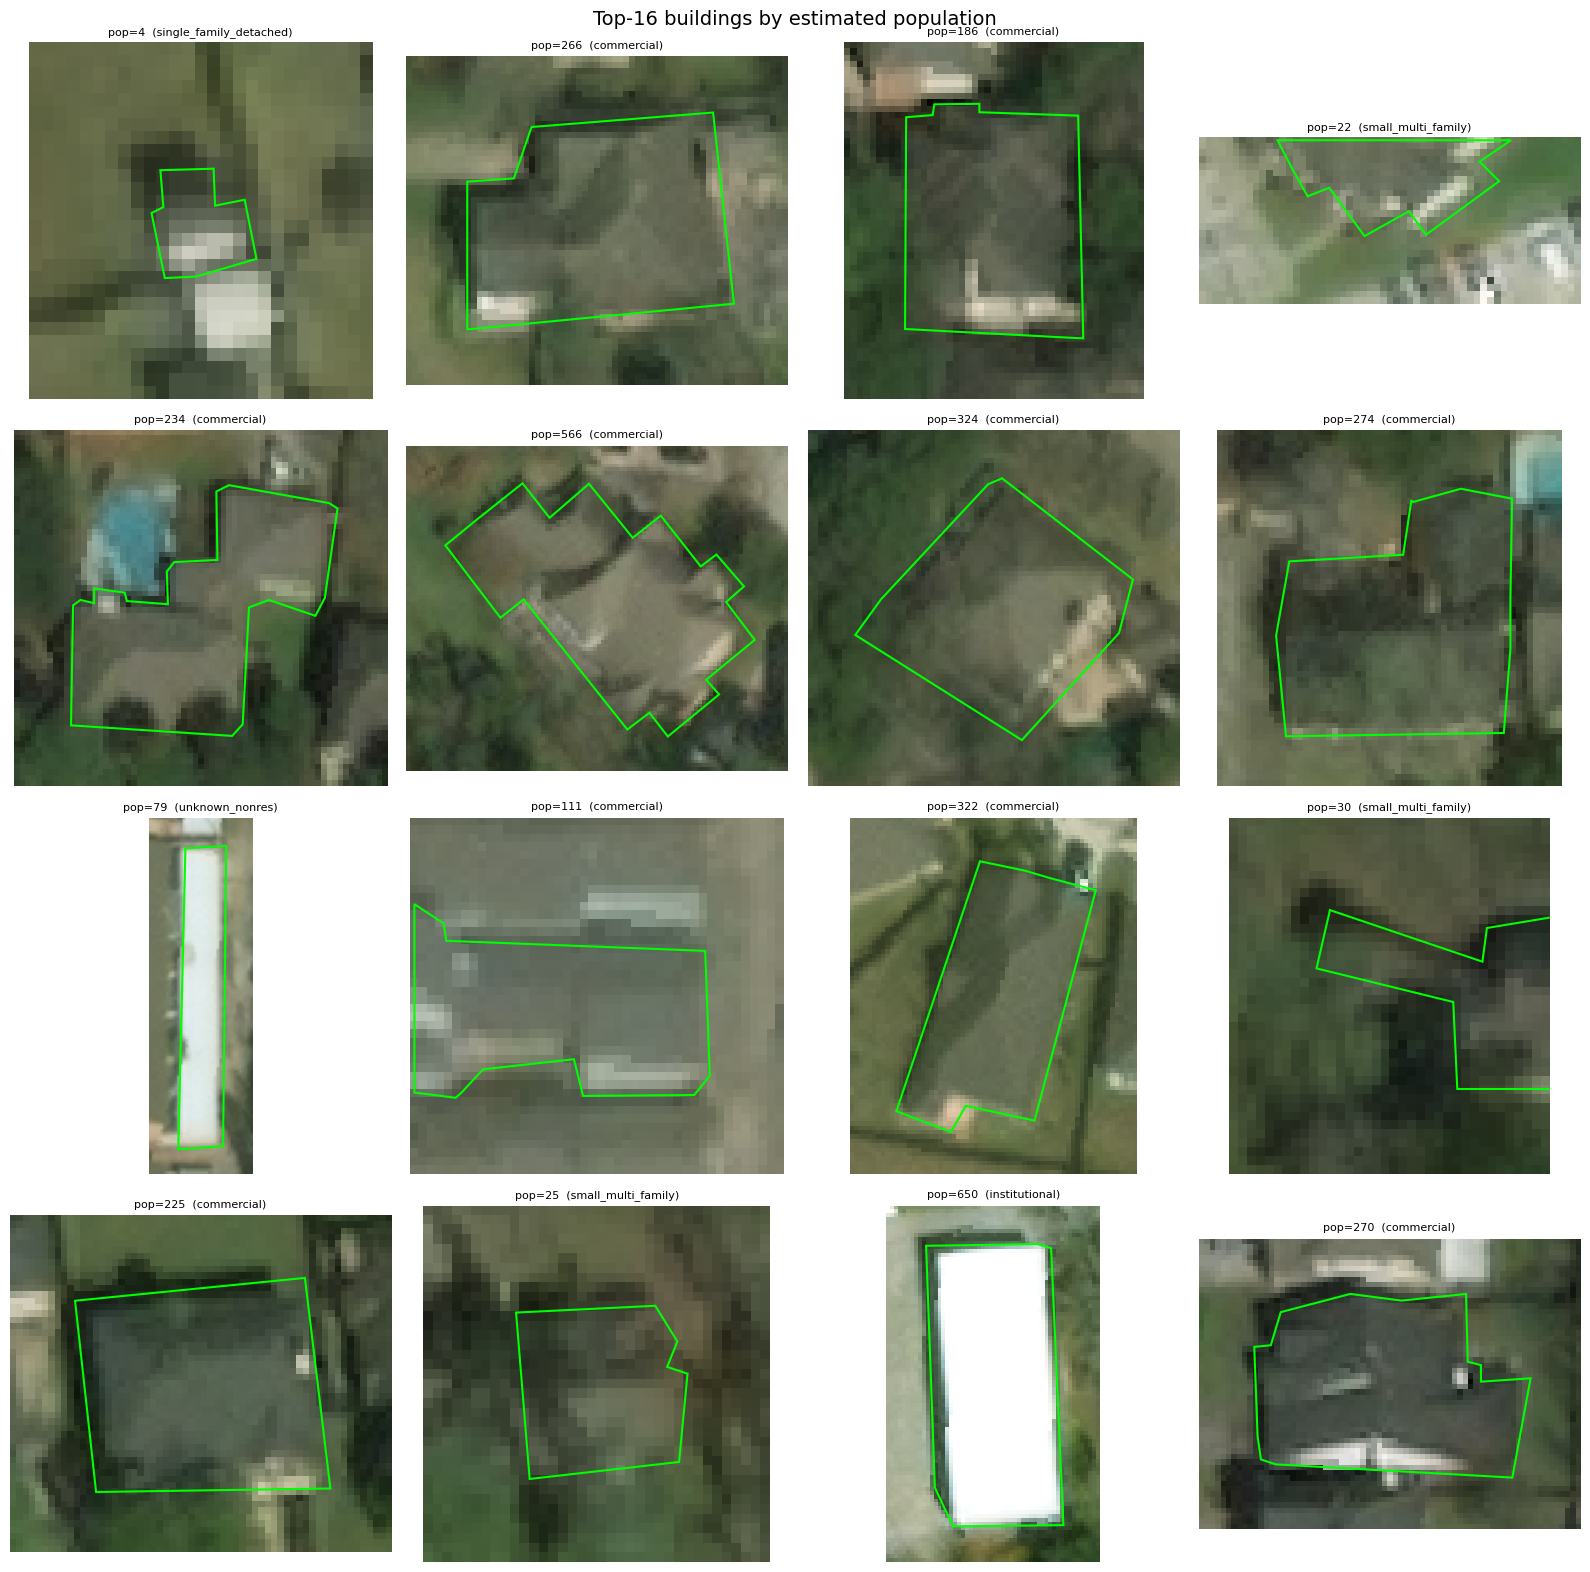

In [14]:
# 5a. Grid of random building crops with estimated population

sample = joined.sample(min(16, len(joined)))

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img = Image.open(row["crop_path"])
    ax.imshow(img)

    poly_px = wkt.loads(row["poly_px_wkt"])
    bx0, by0 = row["bbox_px"][0], row["bbox_px"][1]
    shifted = [(x - bx0, y - by0) for x, y in poly_px.exterior.coords]
    ax.add_patch(plt.Polygon(shifted, fill=False, edgecolor="lime", linewidth=1.5))

    pop = row["estimated_population"]
    btype = row["building_type"]
    ax.set_title(f"pop={pop:.0f}  ({btype})", fontsize=8)
    ax.axis("off")
fig.suptitle("Top-16 buildings by estimated population", fontsize=14)
plt.tight_layout()
plt.show()

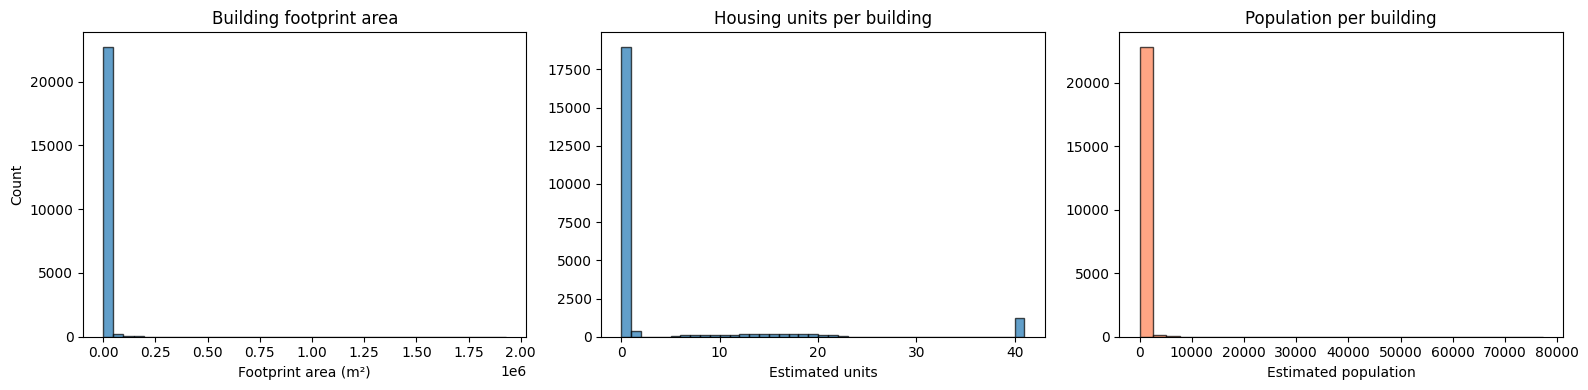

In [15]:
# 5b. Histograms of key features

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(joined["footprint_m2"], bins=40, edgecolor="k", alpha=0.7)
axes[0].set_xlabel("Footprint area (m²)")
axes[0].set_ylabel("Count")
axes[0].set_title("Building footprint area")

axes[1].hist(joined["estimated_units"], bins=range(0, joined["estimated_units"].max() + 2),
             edgecolor="k", alpha=0.7)
axes[1].set_xlabel("Estimated units")
axes[1].set_title("Housing units per building")

axes[2].hist(joined["estimated_population"], bins=30, edgecolor="k", alpha=0.7, color="coral")
axes[2].set_xlabel("Estimated population")
axes[2].set_title("Population per building")

plt.tight_layout()
plt.show()

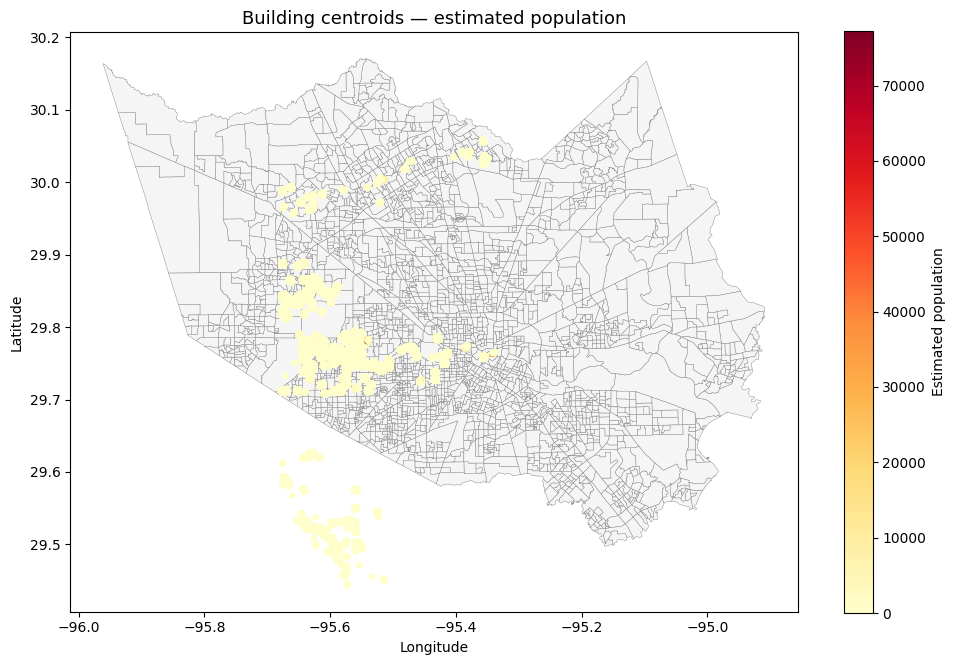

In [16]:
# 5c. Map of building centroids coloured by population

map_gdf = gpd.GeoDataFrame(
    joined,
    geometry=gpd.points_from_xy(joined.centroid_lng, joined.centroid_lat),
    crs="EPSG:4326",
)

fig, ax = plt.subplots(figsize=(10, 10))
harris_cbgs_acs.plot(ax=ax, color="whitesmoke", edgecolor="grey", linewidth=0.3)
sc = map_gdf.plot(
    ax=ax, column="estimated_population", cmap="YlOrRd",
    markersize=15, legend=True,
    legend_kwds={"label": "Estimated population", "shrink": 0.6},
)
ax.set_title("Building centroids — estimated population", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

In [17]:
# 5d. Save ML-ready dataset
#
# Each row = one building with:
#   - paths to cropped image + binary mask
#   - building polygon (pixel + geographic WKT)
#   - building type (detailed + simplified 5-class)
#   - estimated population (regression target)
#   - demographic features from ACS

ml_cols = [
    "building_uid", "tile_base",
    "crop_path", "mask_path",
    "crop_w", "crop_h", "footprint_m2", "gsd",
    "poly_px_wkt", "poly_geo_wkt",
    "centroid_lng", "centroid_lat",
    "GEOID",
    "building_type", "type_class", "type_class_name",
    "is_residential", "estimated_units",
    "occupancy_rate", "classification_source",
    "estimated_population",
]

ppu_cols = [c for c in joined.columns if c.startswith("ppu_")]
ml_cols += ppu_cols

ml_dataset = joined[[c for c in ml_cols if c in joined.columns]].copy()

out_csv = OUTPUT_DIR / "labels.csv"
ml_dataset.to_csv(out_csv, index=False)
print(f"Saved {len(ml_dataset)} rows to {out_csv}")
print(f"  Crops dir  : {CROPS_DIR}/ ({len(list(CROPS_DIR.glob('*.png')))} files)")
print(f"  Masks dir  : {MASKS_DIR}/ ({len(list(MASKS_DIR.glob('*.png')))} files)")
print(f"  Labels file: {out_csv}")
print(f"\nClass distribution:")
print(ml_dataset["type_class_name"].value_counts())
print(f"\nPopulation stats:")
print(ml_dataset["estimated_population"].describe().round(1))
ml_dataset.head()

Saved 23014 rows to ml_dataset/labels.csv
  Crops dir  : ml_dataset/crops/ (23014 files)
  Masks dir  : ml_dataset/masks/ (23014 files)
  Labels file: ml_dataset/labels.csv

Class distribution:
type_class_name
commercial           17392
residential_multi     3687
other                  954
institutional          632
residential_small      349
Name: count, dtype: int64

Population stats:
count    23014.0
mean       289.6
std        880.8
min          0.0
25%        101.5
50%        215.8
75%        302.1
max      77234.1
Name: estimated_population, dtype: float64


,building_uid,tile_base,crop_path,mask_path,crop_w,crop_h,footprint_m2,gsd,poly_px_wkt,poly_geo_wkt,...,classification_source,estimated_population,ppu_single_family_detached,ppu_mobile_home,ppu_duplex,ppu_triplex,ppu_multi_family,ppu_small_multi_family,ppu_large_multi_family,ppu_unknown
0,c5549b70-5902-482a-9817-75dcc952a7be,hurricane-harvey_00000000,ml_dataset/crops/hurricane-harvey_00000000_c55...,ml_dataset/masks/hurricane-harvey_00000000_c55...,29,67,2124.474129,1.902296,"POLYGON ((0 161.2752834161872, 7.5281032424866...","POLYGON ((-95.4892325930414 29.76927046175237,...",...,area_heuristic,85.0,2.902778,2.902778,2.5,2.2,1.92,2.0,1.8,2.411389
1,e3c03011-607b-47d3-a12c-6be51c583783,hurricane-harvey_00000000,ml_dataset/crops/hurricane-harvey_00000000_e3c...,ml_dataset/masks/hurricane-harvey_00000000_e3c...,97,132,15440.181958,1.902296,"POLYGON ((195.0499158724838 424.4277568004801,...",POLYGON ((-95.48826380266624 29.76818011998131...,...,area_heuristic,617.6,2.902778,2.902778,2.5,2.2,1.92,2.0,1.8,2.411389
2,c3dd022f-8ace-43b6-a8a6-6e046b10663d,hurricane-harvey_00000000,ml_dataset/crops/hurricane-harvey_00000000_c3d...,ml_dataset/masks/hurricane-harvey_00000000_c3d...,48,46,1586.518356,1.902296,"POLYGON ((158.277012491073 508.2166269565598, ...",POLYGON ((-95.48843255564391 29.76782396613615...,...,area_heuristic,31.9,2.902778,2.902778,2.5,2.2,1.92,2.0,1.8,2.411389
3,5f386fbd-034c-408f-b059-f16004c81cee,hurricane-harvey_00000000,ml_dataset/crops/hurricane-harvey_00000000_5f3...,ml_dataset/masks/hurricane-harvey_00000000_5f3...,165,94,21795.467219,1.902296,"POLYGON ((0 590.074969171378, 13.5675914715940...",POLYGON ((-95.48918792436406 29.76746489997759...,...,area_heuristic,871.8,2.902778,2.902778,2.5,2.2,1.92,2.0,1.8,2.411389
4,e451d953-9182-4788-afa1-00c4398038d5,hurricane-harvey_00000000,ml_dataset/crops/hurricane-harvey_00000000_e45...,ml_dataset/masks/hurricane-harvey_00000000_e45...,46,45,1009.788491,1.902296,"POLYGON ((130.4465553029492 609.9510235442259,...",POLYGON ((-95.48855627967878 29.76739306072397...,...,parcel_code,0.0,2.902778,2.902778,2.5,2.2,1.92,2.0,1.8,2.411389


Building UID : 7cb8f603-51f8-453b-b3b5-3f1235ddd9c1
Tile         : hurricane-harvey_00000347
Centroid     : (-95.59264, 29.76756)
Footprint    : 6058.9 m²
CBG GEOID    : 482014507003
Building type: commercial
Est. units   : 0
Occupancy    : 0.85
Est. pop     : 242.4


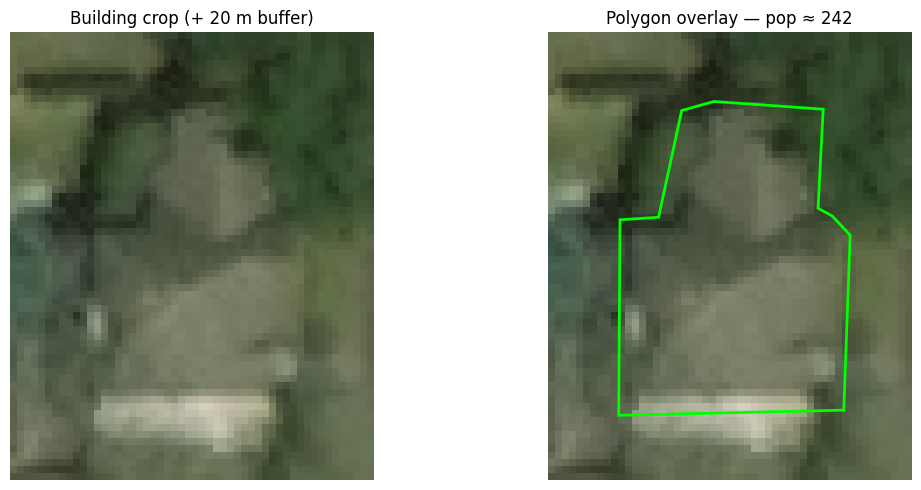

In [18]:
# 5e. Quick sanity check – show one building end-to-end

sample_row = joined.sample(100).iloc[0]

print(f"Building UID : {sample_row['building_uid']}")
print(f"Tile         : {sample_row['tile_base']}")
print(f"Centroid     : ({sample_row['centroid_lng']:.5f}, {sample_row['centroid_lat']:.5f})")
print(f"Footprint    : {sample_row['footprint_m2']:.1f} m²")
print(f"CBG GEOID    : {sample_row.get('GEOID', 'N/A')}")
print(f"Building type: {sample_row['building_type']}")
print(f"Est. units   : {sample_row['estimated_units']}")
print(f"Occupancy    : {sample_row.get('occupancy_rate', DEFAULT_OCCUPANCY):.2f}")
print(f"Est. pop     : {sample_row['estimated_population']}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: the cropped building image
crop_img = Image.open(sample_row["crop_path"])
axes[0].imshow(crop_img)
axes[0].set_title("Building crop (+ 20 m buffer)")
axes[0].axis("off")

# Right: building polygon overlay on crop
poly_px = wkt.loads(sample_row["poly_px_wkt"])
bbox = sample_row["bbox_px"]
shifted_coords = [(x - bbox[0], y - bbox[1]) for x, y in poly_px.exterior.coords]
poly_patch = plt.Polygon(shifted_coords, fill=False, edgecolor="lime", linewidth=2)
axes[1].imshow(crop_img)
axes[1].add_patch(poly_patch)
axes[1].set_title(f"Polygon overlay — pop ≈ {sample_row['estimated_population']:.0f}")
axes[1].axis("off")

plt.tight_layout()
plt.show()